<a href="https://colab.research.google.com/github/prathameshmowade/Patern-Recognition-/blob/main/PR_6_CM53.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


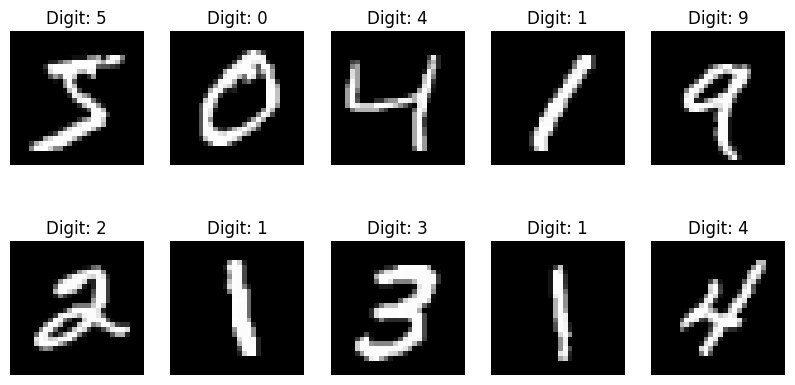

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title("Digit: "+str(y_train[i]))
    plt.axis("off")

plt.show()

In [4]:
X_train_flat = X_train.reshape(X_train.shape[0], 28*28)
X_test_flat = X_test.reshape(X_test.shape[0], 28*28)

print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


In [5]:
X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat / 255.0

In [6]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_flat, y_train)

KNeighborsClassifier(n_neighbors=3)

In [7]:
y_pred = knn.predict(X_test_flat)

In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy*100,"%")

Accuracy : 97.05 %


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.96      1.00      0.98      1135
           2       0.98      0.97      0.97      1032
           3       0.96      0.97      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.96      0.96       892
           6       0.98      0.99      0.98       958
           7       0.96      0.96      0.96      1028
           8       0.99      0.94      0.96       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 974    1    1    0    0    1    2    1    0    0]
 [   0 1133    2    0    0    0    0    0    0    0]
 [  10    9  996    2    0    0    0   13    2    0]
 [   0    2    4  976    1   13    1    7    3    3]
 [   1    6    0    0  950    0    4    2    0   19]
 [   6    1    0   11    2  859    5    1    3    4]
 [   5    3    0    0    3    3  944    0    0    0]
 [   0   21    5    0    1    0    0  991    0   10]
 [   8    2    4   16    8   11    3    4  914    4]
 [   4    5    2    8    9    2    1    8    2  968]]


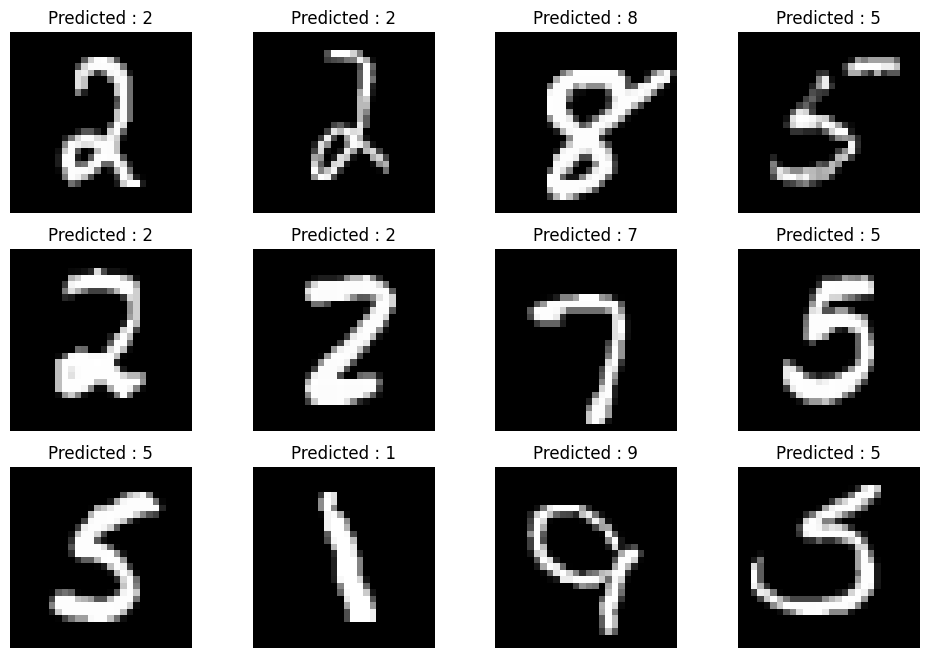

In [11]:
plt.figure(figsize=(12,8))

for i in range(12):

    index = np.random.randint(0,len(X_test))

    image = X_test[index]

    prediction = knn.predict(image.reshape(1,784)/255.0)

    plt.subplot(3,4,i+1)
    plt.imshow(image,cmap='gray')
    plt.title("Predicted : "+str(prediction[0]))
    plt.axis("off")

plt.show()

In [12]:
from scipy.ndimage import rotate

rotated_images = []
rotated_labels = []

for i in range(500):

    img = X_test[i]

    angle = np.random.randint(-20,20)

    new_img = rotate(img, angle, reshape=False)

    rotated_images.append(new_img)

    rotated_labels.append(y_test[i])

rotated_images = np.array(rotated_images)
rotated_labels = np.array(rotated_labels)

In [13]:
rotated_images = rotated_images.reshape(500,784)

rotated_images = rotated_images/255.0

pred = knn.predict(rotated_images)

acc = accuracy_score(rotated_labels,pred)

print("Accuracy on Different Writing Styles :",acc*100,"%")

Accuracy on Different Writing Styles : 95.0 %


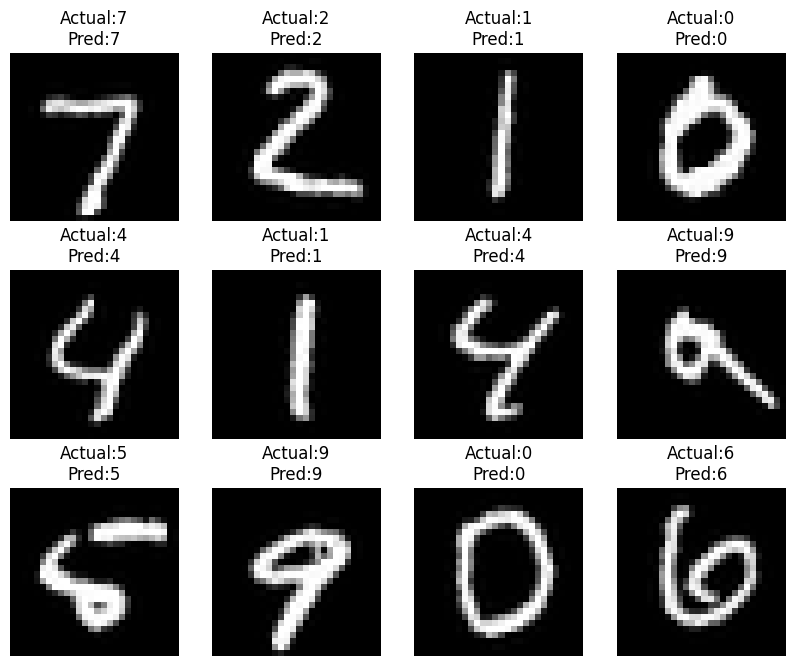

In [14]:
plt.figure(figsize=(10,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(rotated_images[i].reshape(28,28),cmap='gray')

    plt.title("Actual:"+str(rotated_labels[i])+
              "\nPred:"+str(pred[i]))

    plt.axis("off")

plt.show()